C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


膚色分析結果： [144 108  80]
穿搭建議（依膚色）：
 暖色調建議：
1. 杏色、奶油白、鵝黃、卡其色
2. 珊瑚粉、橘紅、磚紅
3. 墨綠、深藍、焦糖棕
4. 金屬光澤系（金、香檳）
體型判斷結果： 梨型
穿搭建議（依體型）：
 建議上半身穿亮色，吸引視線上移


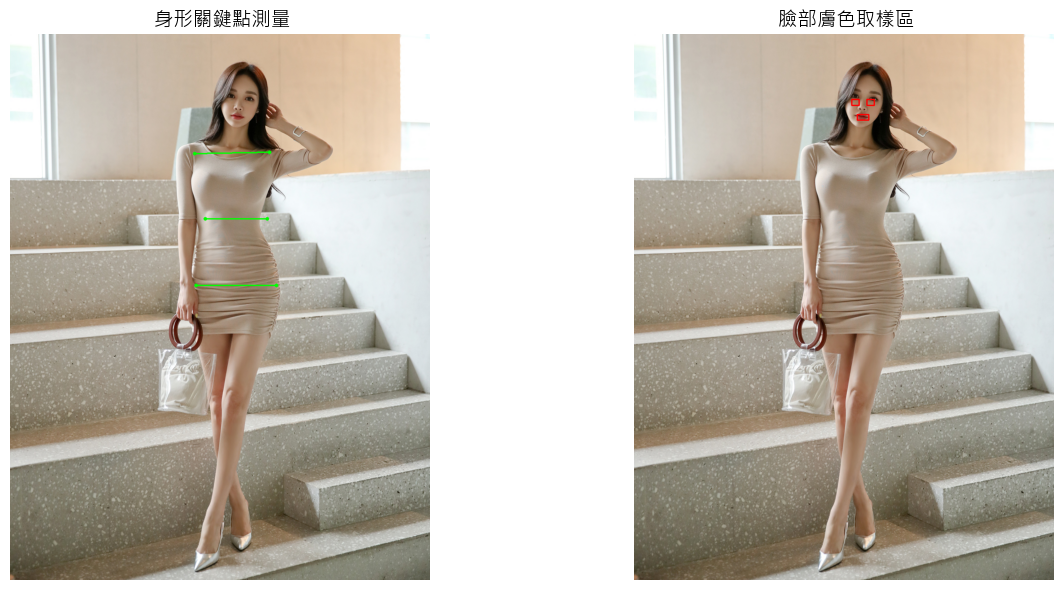

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from sklearn.cluster import KMeans
import matplotlib

# 中文顯示設定
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# === 讀取圖像 ===
img_path =r"C:\AI\e6de-iatixpk5884173.png"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === 使用 MediaPipe 偵測臉部 ===
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils
face_detection = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

results = face_detection.process(img_rgb)
face_imgs = []
region_coords = []
img_with_face_boxes = img_rgb.copy()

if results.detections:
    for detection in results.detections:
        bbox = detection.location_data.relative_bounding_box
        ih, iw, _ = img_rgb.shape
        x, y, w, h = int(bbox.xmin * iw), int(bbox.ymin * ih), int(bbox.width * iw), int(bbox.height * ih)

        regions = [
            ((x + int(w * 0.2), y + int(h * 0.35)), (x + int(w * 0.4), y + int(h * 0.5))),
            ((x + int(w * 0.6), y + int(h * 0.35)), (x + int(w * 0.8), y + int(h * 0.5))),
            ((x + int(w * 0.35), y + int(h * 0.75)), (x + int(w * 0.65), y + int(h * 0.9)))
        ]

        for (x1, y1), (x2, y2) in regions:
            region = img_rgb[y1:y2, x1:x2]
            face_imgs.append(region)
            region_coords.append(((x1, y1), (x2, y2)))
            cv2.rectangle(img_with_face_boxes, (x1, y1), (x2, y2), (255, 0, 0), 2)
else:
    h, w, _ = img_rgb.shape
    regions = [
        ((int(w * 0.4), int(h * 0.4)), (int(w * 0.5), int(h * 0.5))),
        ((int(w * 0.4), int(h * 0.5)), (int(w * 0.5), int(h * 0.6))),
        ((int(w * 0.4), int(h * 0.6)), (int(w * 0.5), int(h * 0.7)))
    ]
    for (x1, y1), (x2, y2) in regions:
        region = img_rgb[y1:y2, x1:x2]
        face_imgs.append(region)
        region_coords.append(((x1, y1), (x2, y2)))
        cv2.rectangle(img_with_face_boxes, (x1, y1), (x2, y2), (255, 0, 0), 2)

# === 膚色分析區塊（取三個主色） ===
def is_skin(rgb):
    r, g, b = rgb
    return (r > 90) and (g > 40) and (b > 20) and ((max(rgb) - min(rgb)) > 15) and (abs(r - g) > 15) and (r > g) and (r > b)

dominant_colors = []

for region in face_imgs:
    pixels = region.reshape(-1, 3)
    skin_pixels = np.array([px for px in pixels if is_skin(px)])

    # 若過少則使用所有像素防止 KMeans 異常
    if len(skin_pixels) < 10:
        skin_pixels = pixels

    # KMeans 分3群
    kmeans = KMeans(n_clusters=3, random_state=0, n_init=10).fit(skin_pixels)
    colors = kmeans.cluster_centers_.astype(int)

    # 將3個主色存入 dominant_colors
    dominant_colors.extend(colors)

# === 身形分析與關鍵點視覺化 ===
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)
results = pose.process(img_rgb)

img_pose_vis = img_rgb.copy()
body_type = "無法判斷"
advice_body = "⚠️ 未偵測到人體關鍵點"

if results.pose_landmarks:
    h, w, _ = img.shape
    landmarks = results.pose_landmarks.landmark

    def get_xy(index):
        return int(landmarks[index].x * w), int(landmarks[index].y * h)

    shoulder_left = get_xy(mp_pose.PoseLandmark.LEFT_SHOULDER.value)
    shoulder_right = get_xy(mp_pose.PoseLandmark.RIGHT_SHOULDER.value)
    hip_l = get_xy(mp_pose.PoseLandmark.LEFT_HIP.value)
    hip_r = get_xy(mp_pose.PoseLandmark.RIGHT_HIP.value)
    hip_y = int((hip_l[1] + hip_r[1]) / 2)
    hip_left = (min(hip_l[0], hip_r[0]) - int(0.05 * w), hip_y)
    hip_right = (max(hip_l[0], hip_r[0]) + int(0.05 * w), hip_y)

    mid_shoulder_y = int((shoulder_left[1] + shoulder_right[1]) / 2)
    mid_hip_y = int((hip_l[1] + hip_r[1]) / 2)
    waist_y = int((mid_shoulder_y + mid_hip_y) / 2)
    hip_width_raw = abs(hip_r[0] - hip_l[0])
    waist_margin = int(hip_width_raw * 0.3)
    waist_left = (hip_l[0] + waist_margin, waist_y)
    waist_right = (hip_r[0] - waist_margin, waist_y)

    cv2.line(img_pose_vis, shoulder_left, shoulder_right, (0, 255, 0), 2)
    cv2.line(img_pose_vis, waist_left, waist_right, (0, 255, 0), 2)
    cv2.line(img_pose_vis, hip_left, hip_right, (0, 255, 0), 2)
    for pt in [shoulder_left, shoulder_right, waist_left, waist_right, hip_left, hip_right]:
        cv2.circle(img_pose_vis, pt, 4, (0, 255, 0), -1)

    shoulder_width = np.linalg.norm(np.array(shoulder_right) - np.array(shoulder_left))
    waist_width = np.linalg.norm(np.array(waist_right) - np.array(waist_left))
    hip_width = np.linalg.norm(np.array(hip_right) - np.array(hip_left))

    def classify_body_type(shoulder, waist, hip):
        ratio_shoulder_hip = shoulder / hip
        ratio_waist_shoulder = waist / shoulder
        ratio_waist_hip = waist / hip

        if 0.95 <= ratio_shoulder_hip <= 1.5 and ratio_waist_shoulder < 0.9 and 0.6< ratio_waist_hip < 0.9:
            return "沙漏型", "適合合身剪裁衣物、展現曲線"
        elif ratio_shoulder_hip > 1.5:
            return "倒三角型", "建議穿著下身寬鬆款式，平衡比例"
        elif ratio_shoulder_hip < 0.95:
            return "梨型", "建議上半身穿亮色，吸引視線上移"
        elif ratio_waist_shoulder >= 0.9 and ratio_waist_hip >= 0.9:
            return "蘋果型", "建議強調腿部與肩線，選擇高腰設計"
        else:
            return "矩形", "可透過腰帶等方式強調腰線"

    body_type, advice_body = classify_body_type(shoulder_width, waist_width, hip_width)

# === 膚色分類與建議 ===
def classify_skin_tone(rgb):
    r, g, b = rgb
    if r > g and r > b and r - b > 30:
        return "暖色調建議：\n1. 杏色、奶油白、鵝黃、卡其色\n2. 珊瑚粉、橘紅、磚紅\n3. 墨綠、深藍、焦糖棕\n4. 金屬光澤系（金、香檳）"
    elif b > r and b > g:
        return "冷色調建議：\n1. 冰藍、深藍\n2. 紫色系\n3. 灰色、銀色\n4. 粉紅、裸粉"
    else:
        return "中性色調建議：\n白、灰、墨綠等百搭色，任何風格皆可輕鬆駕馭"

advice_skin = "⚠️ 無有效膚色可分析"
if dominant_colors:
    dominant_color = dominant_colors[0]
    advice_skin = classify_skin_tone(dominant_color)

# === 結果輸出 ===
print("膚色分析結果：", dominant_colors[0] if dominant_colors else "無")
print("穿搭建議（依膚色）：\n", advice_skin)
print("體型判斷結果：", body_type)
print("穿搭建議（依體型）：\n", advice_body)

# === 顯示圖像 ===
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(img_pose_vis)
axs[0].set_title(" 身形關鍵點測量", fontsize=14)
axs[0].axis('off')

axs[1].imshow(img_with_face_boxes)
axs[1].set_title(" 臉部膚色取樣區", fontsize=14)
axs[1].axis('off')

plt.tight_layout()
plt.show()
